## SECTION 5-1. 결정 트리

In [1]:
# 샘플 데이터 가져오기
import pandas as pd
wine = pd.read_csv("https://raw.githubusercontent.com/rickiepark/hongong-ml/master/wine.csv")

# 처음 5개 샘플 확인
wine.head()

,alcohol,sugar,pH,class
0,9.4,1.9,3.51,0.0
1,9.8,2.6,3.20,0.0
2,9.8,2.3,3.26,0.0
3,9.8,1.9,3.16,0.0
4,9.4,1.9,3.51,0.0


In [2]:
# info 메서드: 데이터 프레임의 각 열의 데이터 타입 & 누락된 데이터 있는지 확인

wine.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   alcohol  6497 non-null   float64
 1   sugar    6497 non-null   float64
 2   pH       6497 non-null   float64
 3   class    6497 non-null   float64
dtypes: float64(4)
memory usage: 203.2 KB


In [3]:
# describe() 메서드: 열에 대한 간략한 통계 등 출력

wine.describe()

,alcohol,sugar,pH,class
count,6497.000000,6497.000000,6497.000000,6497.000000
mean,10.491801,5.443235,3.218501,0.753886
std,1.192712,4.757804,0.160787,0.430779
min,8.000000,0.600000,2.720000,0.000000
25%,9.500000,1.800000,3.110000,1.000000
50%,10.300000,3.000000,3.210000,1.000000
75%,11.300000,8.100000,3.320000,1.000000
max,14.900000,65.800000,4.010000,1.000000


In [4]:
# 판다스 데이터프레임을 훈련 세트 / 테스트 세트로 분할
data = wine[['alcohol', 'sugar', 'pH']]
target = wine['class']

from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
    data, target, test_size=0.2, random_state=42
)

# 훈련 세트 & 테스트 세트 크기 확인
print(train_input.shape, test_target.shape)

(5197, 3) (1300,)


In [5]:
# StandardScaler 사용해 훈련 세트 전처리 & 테스트 세트 변환

from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

In [6]:
# 표준 점수로 변환된 train_scaled & test_scaled 사용해 로지스틱 회귀 모델 훈련

from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(train_scaled, train_target)
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

0.7808350971714451
0.7776923076923077


In [7]:
# 설명하기 쉬운 모델 & 어려운 모델
    # 모델 설명 위한 보고서 작성 위해 로지스틱 회귀가 학습한 계수 & 절편 출력

print(lr.coef_, lr.intercept_)

[[ 0.51268071  1.67335441 -0.68775646]] [1.81773456]


In [8]:
# DecisionTreeClassifier 클래스 사용해 결정 트리 모델 훈련
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(train_scaled, train_target)
print(dt.score(train_scaled, train_target))
print(dt.score(test_scaled, test_target))

0.996921300750433
0.86


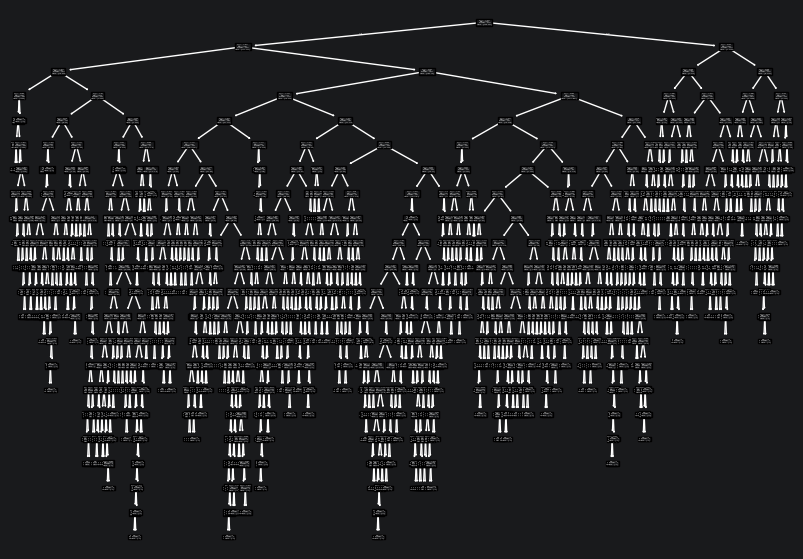

In [9]:
# plot_tree()함수 사용해 결정 트리를 이해하기 쉬운 트리 그림으로 출력

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(10, 7))
plot_tree(dt)
plt.show()

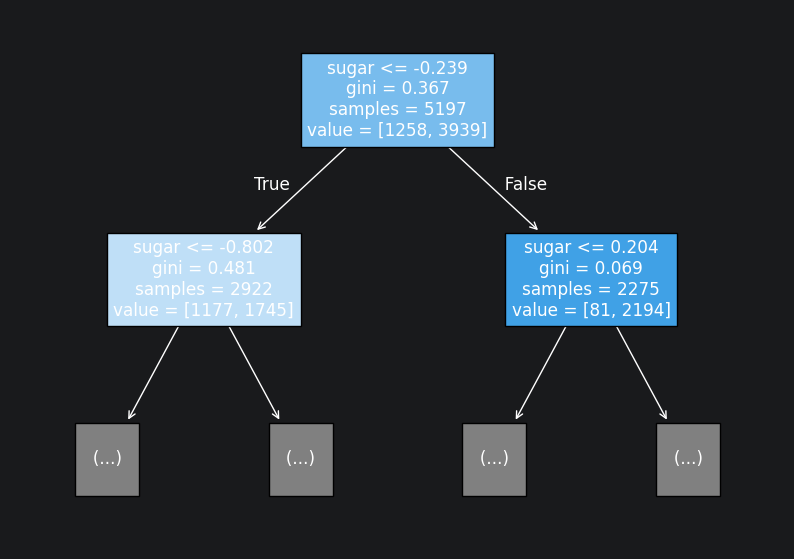

In [10]:
# 사이킷런의 DecisionTreeClassifier 클래스 사용 -> 결정 트리 모델 훈련
    # plot_tree() 함수: 트리 깊이 제한해 출력
    # max_depth 매개변수 1: 루트 노드 네외하고 하나 노드 더 확장
    # filled 매개변수: 클래스 맞게 노드 색깔 조정
    # feature_names 매개변수: 특성 이름 전달
plt.figure(figsize=(10, 7))
plot_tree(dt, max_depth=1, filled=True, feature_names=['alcohol', 'sugar', 'pH'])
plt.show()

- 결정 트리(Decision Tree)
    - 불순도(impurity)
        - gini: 지니 불순도 의미
        - DecisionTreeClassifier 클래스의 criterion 매개변수 기본값: 'gini'
        - criterion 매개변수: 노드에서 데이터 분할하는 기준
        - $지니 불순도 = 1 - (음성 클래스 비율^2 + 양성 클래스 비율^2)$
        - 순수도: 노드에 하나의 클래스만 존재 -> 지니 불순도 0인 노드
            - $ 1 - ((0/100)^2 + (100/100)^2) = 0$
        - 결정 트리 모델: 부모 노드 & 자식 노드의 불순도 차이 가능한 크도록 트리 성정
        - 정보 이득(informaion gain): 부모 노드 & 자식 노드 차이
            - $부모의 불순도 - \dfrac{왼쪽 노드 샘플 수}{부모의 샘플 수} \times 왼쪽 노드 불순도 - \dfrac{오른쪽 노드 샘플 수}{부모 샘플 수} \times 오른쪽 노드 불순도$
        - 엔트로피 불순도: DecisionTreeClassifier 클래스에서 criterion = 'entropy' 지정해 사용
            - $ -음성 클래스 비율 \times \log _2(음성 클래스 비욜) - 양성 클래스 비율 \times \log _2(양성 클래스 비율)$
        - 결정 트리 알고리즘
            - 불순도 기준 사용 -> 정보 이득 최대 되도록 노드 분할
            - 노드 순수하게 나눌수록 정보 이득 확대
            - 새로운 샘플에 대해 예측 시 노드 질문 따라 트리 이동
            - 마지막에 도달한 노드의 클래스 비율 보고 예측

- 가지치기
    - 결정 트리에서 자라날 수 있는 트리의 최대 깊이 제한

In [11]:
# DecisionTreeclassifier 클래스의 max_depth 매개변수 3 지정

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(train_scaled, train_target)
print(dt.score(train_scaled, train_target))
print(dt.score(test_scaled, test_target))

0.8454877814123533
0.8415384615384616


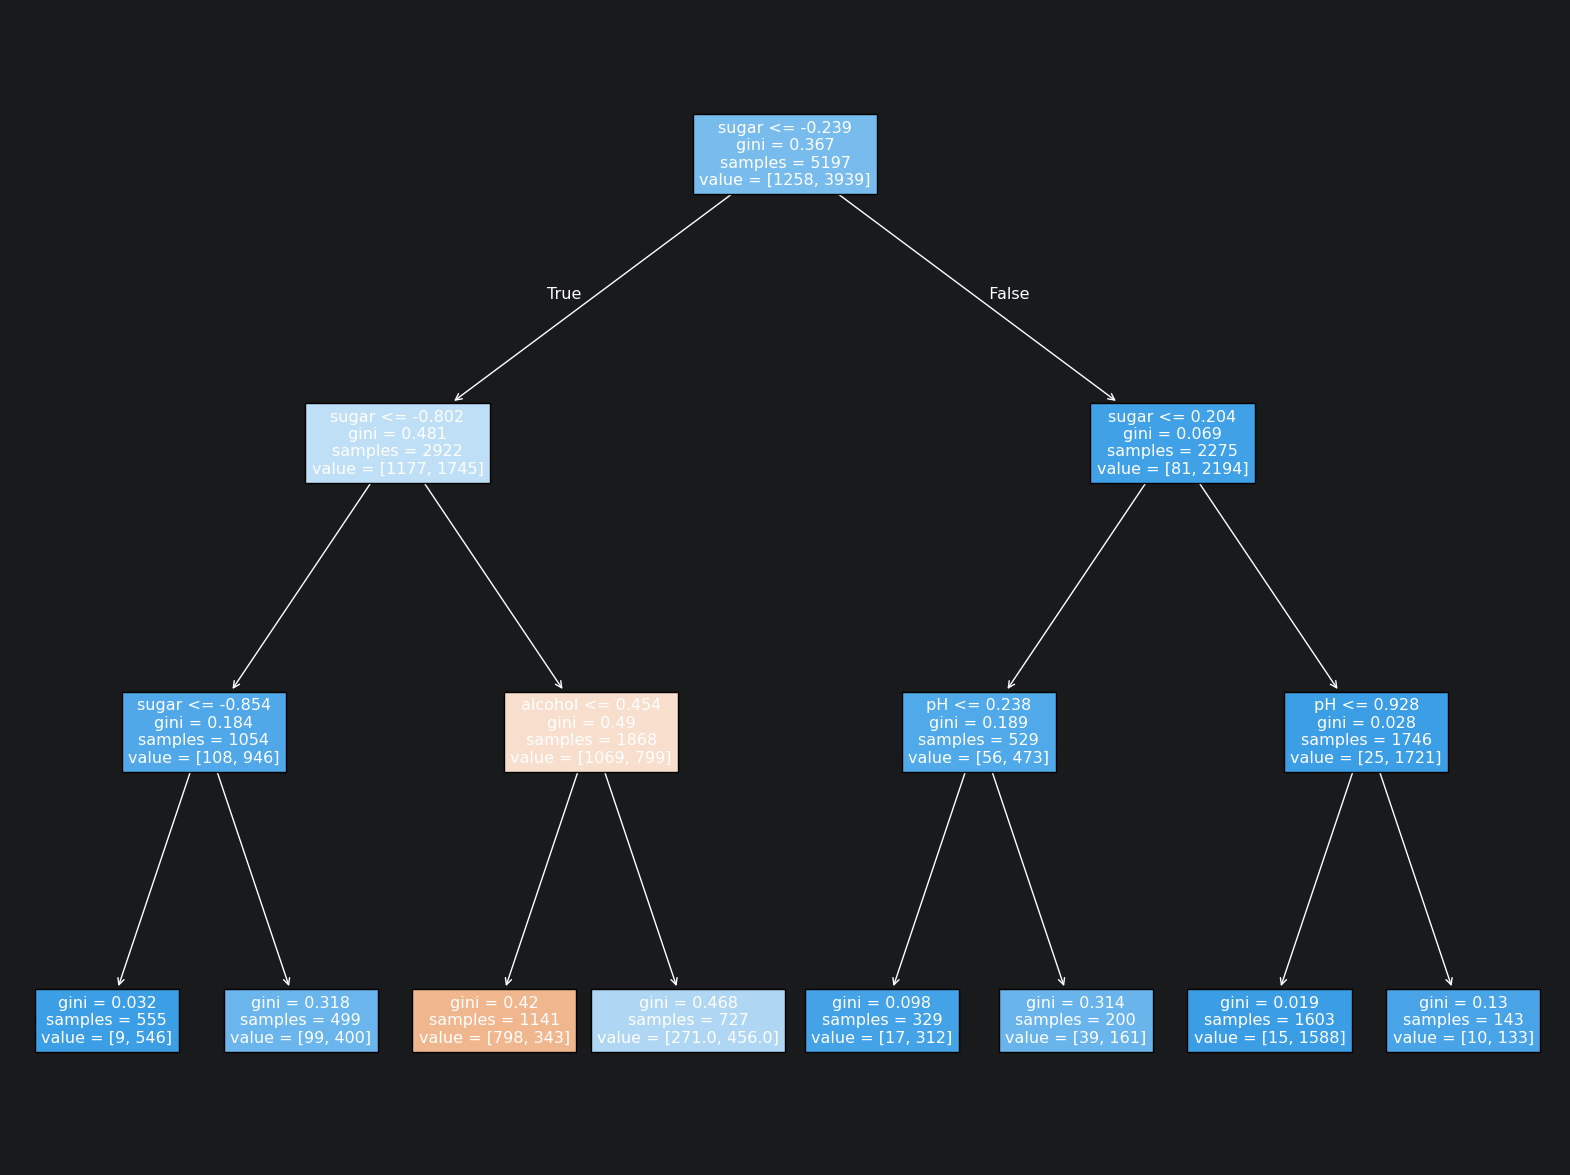

In [12]:
# plot_tree() 함수로 트리 그래프 작성
plt.figure(figsize=(20,15))
plot_tree(dt, filled=True, feature_names=['alcohol', 'sugar', 'pH'])
plt.show()

0.8454877814123533
0.8415384615384616


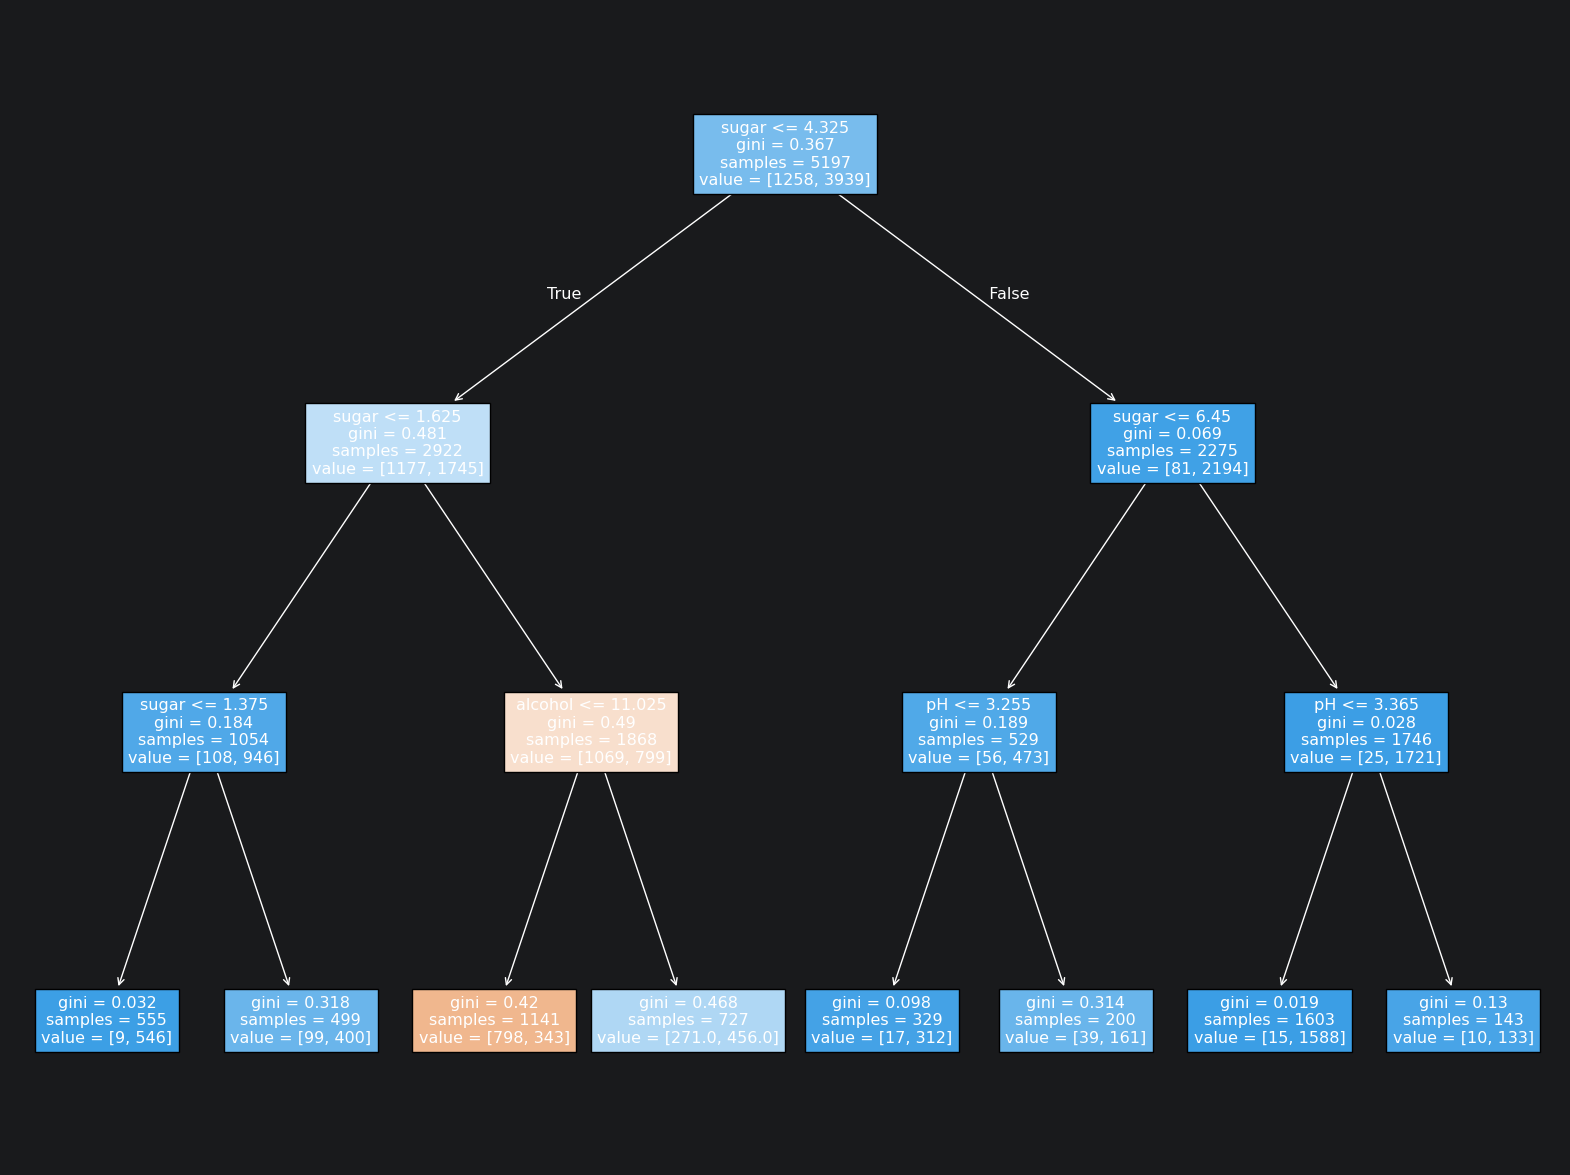

In [13]:
# 특성값의 스케일: 결정 트리 알고리즘에 아무런 영향X -> 표준화 전처리 필요X
# 전처리 전 훈련 세트 & 테스트 세트로 결정 트리 모델 재훈련

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(train_input, train_target)
print(dt.score(train_input, train_target))
print(dt.score(test_input, test_target))

# 트리 그래프로 구현
plt.figure(figsize=(20,15))
plot_tree(dt, filled=True, feature_names=['alcohol', 'sugar', 'pH'])
plt.show()

In [14]:
# 결정 트리: 어떤 특성이 가장 유용한지 나타내는 특성 중요도 계산
# 특성 중요도: 결정 트리 모델의 feature_importances_ 속성에 저장
print(dt.feature_importances_)

[0.12345626 0.86862934 0.0079144 ]


## SECTION 5-2. 교차 검증과 그리드 서치

- 검증 세트
    - 검증 세트: 테스트 세트 사용X, 모델이 과대적합인지 과소적합인지 측정하기 위해 다시 나눠진 훈련 세트

In [15]:
# 검증 세트 만들기

# 판다스로 csv 데이터 읽기
import pandas as pd
wine = pd.read_csv("https://raw.githubusercontent.com/rickiepark/hongong-ml/master/wine.csv")

# 판다스 데이터프레임을 훈련 세트 / 테스트 세트로 분할
data = wine[['alcohol', 'sugar', 'pH']]
target = wine['class']

from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
    data, target, test_size=0.2, random_state=42
)

# 훈련 세트 sub_input, sub_target & 검증 세트 val_input, val_target 만들기
sub_input, val_input, sub_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42
)

In [16]:
# 훈련 세트 & 검증 세트 크기 확인
print(sub_input.shape, val_input.shape)

# 모델 제작 & 평가

from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(sub_input, sub_target)
print(dt.score(sub_input, sub_target))
print(dt.score(val_input, val_target))

(4157, 3) (1040, 3)
0.9971133028626413
0.864423076923077


- 교차 검증(cross validation)
    - 검증 세트 떼어 내어 평가하는 과정 여러 번 반복
    - 점수 평균내어 최종 검증 점수 계산
    - ![5-1](img/chapter05-1.png)

In [17]:
# 사이킷런의 교차 검증 함수 cross_validate()
# 평가할 모델 객체를 첫 번째 매개변수로 전달
# 앞에서처럼 직접 검증 세트 떼어내지 않고 훈련 세트 전체를 cross_validate() 함수에 전달

from sklearn.model_selection import cross_validate
scores = cross_validate(dt, train_input, train_target)
print(scores)

{'fit_time': array([0.01000023, 0.0079987 , 0.00842786, 0.00899816, 0.00800014]), 'score_time': array([0.00200176, 0.00200677, 0.00200033, 0.002002  , 0.00199986]), 'test_score': array([0.87115385, 0.85192308, 0.87776708, 0.85178056, 0.8373436 ])}


{
- 'fit_time': array([0.01000023, 0.0079987 , 0.00842786, 0.00899816, 0.00800014]),    -> 모델 훈련하는 시간
- 'score_time': array([0.00200176, 0.00200677, 0.00200033, 0.002002  , 0.00199986]),  -> 모델 검증하는 시간
- 'test_score': array([0.87115385, 0.85192308, 0.87776708, 0.85178056, 0.8373436 ])
}

In [22]:
# 교차 검증의 최종 점수: test_score 키에 담긴 5개 점수 평균
import numpy as np
print(np.mean(scores['test_score']))

0.8579936329310728


In [24]:
# 분할기 지정
    # cross_validate() 함수는 기본적으로 회귀 모델일 경우 KFold 분할기 사용
    # 분류 모델일 경우 타깃 클래스 골고루 나누기 위해 StratifiedKFold 사용

from sklearn.model_selection import StratifiedKFold
scores = cross_validate(dt, train_input, train_target, cv=StratifiedKFold())
print(np.mean(scores['test_score']))

0.8556846449988894


In [26]:
# 훈련 세트 섞은 후 10-폴드 교차 검증 숳ㅇ

spliter = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_validate(dt, train_input, train_target, cv=spliter)
print(np.mean(scores['test_score']))

0.8593452645620274


- 하이퍼파라미터 튜닝
    - 모델 파라미터: 머신러닝 모델이 학습하는 파라미터
    - 하이퍼파라미터: 모델이 학습 불가능해 사용자가 지정해야만 하는 파라미터
    - 하이퍼파라미터 튜닝 작업 진행
        - 라이브러리가 제공하는 기본값 그대로 사용 -> 모델 훈련
        - 검증 세트의 점수 / 교차 검증 통해 매개변수 조금씩 변화
        - 모델마다 적게는 1 ~ 2개, 많게는 5 ~ 6개 매개변수 제공
        - 매개변수 바꿔가며 모델 훈련, 교차 검증 수행
    - 그리드 서치(Grid Search): max_depth 최적값은 min_samples_split 매개변수 값이 바뀌면 함께 바뀜 -> 두 매개변수 동시에 바꿔가며 최적 값 찾기 위해 사용
        - 사이킷런의 GridSearchCV 이용

In [27]:
# 기본 매개변수 사용한 결정 트리 모델에서 min_impurity_decrease 매개변수 최적값 탐색

# GridSearchCV 클래스 임포트, 탐색할 매개변수 & 값 리스트 딕셔너리화
from sklearn.model_selection import GridSearchCV
params = {'min_impurity_decrease':[0.0001, 0.0002, 0.0003, 0.0004, 0.0005]}

# GridSearchCV 클래스에 탐색 대상 모델 & params 변수 전달 -> 그리드 서치 객체 생성
gs = GridSearchCV(DecisionTreeClassifier(random_state=42), params, n_jobs=-1)

# min_impurity_decrease 값 바꿔가며 총 5번 실행
gs.fit(train_input, train_target)

# 검증 점수 가장 높은 모델의 매개변수 조합으로 전체 훈련 세트에서 자동으로 다시 모델 훈련
dt = gs.best_estimator_
print(dt.score(train_input, train_target))

# 그리드 서치로 찾은 최적 매개변수는 best_params_ 속서엥 저장
print(gs.best_params_)

0.9615162593804117
{'min_impurity_decrease': 0.0001}


In [29]:
# 기본 매개변수 사용한 결정 트리 모델에서 min_impurity_decrease 매개변수 최적값 탐색

# 5번 교차 검증으로 얻은 점수 출력
print(gs.cv_results_['mean_test_score'])

# 이 인덱스 사용해 params 키에 저장된 매개변수 출력
print(gs.cv_results_['params'][gs.best_index_])

[0.86819297 0.86453617 0.86492226 0.86780891 0.86761605]
{'min_impurity_decrease': 0.0001}


In [31]:
# 복잡한 매개변수 조합 탐색
# min_impurity_decrease: 노드 분할 위한 불순도 감소 최소량 지정
# max_depth: 트리 깊이 제한
# min_samples_split: 노드 나누기 위한 최소 샘플 수 선텍
params = {'min_impurity_decrease': np.arange(0.0001, 0.001, 0.0001),    # 0.0001에서 시작, 0.0001씩 더해 0.001 될때까지 계속 더한 배열, 원소 총 9개
          'max_depth': range(5, 20, 1),                                 # 5에서 20까지 1씩 증가하며 15개 값 생성
          'min_samples_split': range(2, 100, 10)                        # 2에서 100까지 10씩 증가하며 10개 값 생성
          }

# 이 매개변수로 수행할 교차 검증 횟수: 9 × 15 × 10 = 1,350개
# 기본 5-폴드 교차검증 수행 -> 만들어지는 모델 수 모두 6,750개

In [32]:
# n_jobs 매개변수 -1 설정 & 그리드 서치 실행
gs = GridSearchCV(DecisionTreeClassifier(random_state=42), params, n_jobs=-1)
gs.fit(train_input, train_target)

# 최상 매개변수 조합 확인
print(gs.best_params_)

# 최상 교차 검증 점수 확인
print(np.max(gs.cv_results_['mean_test_score']))

{'max_depth': 14, 'min_impurity_decrease': np.float64(0.0004), 'min_samples_split': 12}
0.8683865773302731


- 랜덤 서치
    - 매개변수 값이 수치일 때 범위 / 간격 미리 정하기 어려울 때
    - 너무 많은 매개 변수 조건 -> 그리드 서치 시간 오래 걸릴 때
    - 랜덤 서치에는 매개변수 값 목록X, 매개변수 샘플링 가능한 확률 분포 객체 전달

In [33]:
# 싸이파이에서 2개 확률 분포 클래스 임포트
from scipy.stats import uniform, randint

# 0 ~ 10 사이 범위 갖는 raindit 객체 생성, 10개 숫자 샘플링
rgen = randint(0, 10)
rgen.rvs(10)

# 1,000개 샘플링 -> 각 숫자 개수 구하기
np.unique(rgen.rvs(1000), return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 array([ 80,  97, 122, 104, 108,  98, 104,  98,  99,  90]))

In [35]:
# uniform 클래스로 - ~ 1 사이 10개 실수 추출
ugen = uniform(0, 1)
ugen.rvs(10)

array([0.95766296, 0.93023309, 0.27063229, 0.11571844, 0.70953822,
       0.44523904, 0.45784831, 0.42509369, 0.13168603, 0.77718497])

In [36]:
# 탐색할 매개변수 딕셔너리 생성
params = {
    'min_impurity_decrease': uniform(0.0001, 0.001),
    'max_depth': randint(20, 50),
    'min_samples_split': randint(2, 25),
    'min_samples_leaf': randint(1, 25)
}

# 사이킷런의 랜덤 서치 클래스 RandomizedSearchCV의 n_iter 매개변수에 샘플링 횟수 지정
from sklearn.model_selection import RandomizedSearchCV
rs = RandomizedSearchCV(DecisionTreeClassifier(random_state=42), params, n_iter=100, n_jobs=-1, random_state=42)
rs.fit(train_input, train_target)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': <scipy.stats....001E47B9B8530>, 'min_impurity_decrease': <scipy.stats....001E47B984B00>, 'min_samples_leaf': <scipy.stats....001E47B9B9550>, 'min_samples_split': <scipy.stats....001E47B9BAAB0>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User G

In [37]:
# 매개변수 조합 탐색
print(rs.best_params_)

# 최고의 교차 검증 점수 확인
print(np.max(rs.cv_results_['mean_test_score']))

# 최종 모델로 결정, 테스트 세트 성능 확인
dt = rs.best_estimator_
print(dt.score(test_input, test_target))

{'max_depth': 39, 'min_impurity_decrease': np.float64(0.00034102546602601173), 'min_samples_leaf': 7, 'min_samples_split': 13}
0.8695428296438884
0.86


## SECTION 5-3. 트리의 앙상블

- 정형 데이터
    - 어떤 구조로 되어 있는 데이터
    - 머신러닝 알고리즘과 앙상블 학습
    - 위 알고리즘은 대부분 결정 트리 기반으로 생성
- 비정형 데이터
    - 신경망 알고리즘

- 랜덤 포레스트
    - 대표적 앙상플 학습
        - 안정적 성능 -> 널리 사용
        - 결정 트리를 랜덤하게 생성 -> 결정 트리 숲 생성 -> 각 결정 트리 예측을 사용해 최종 예측 도출
    - 부트스트랩 샘플
        - 데이터 세트에서 중복 허용 -> 데이터 샘플링
        - 기본적으로 부트스트랩 샘플 크기 = 훈련 세트 샘플 크기
        - 각 노드 분할 시 전체 특성 중 일부 특성 무작위로 고른 다음 이 중에서 최선의 분할 검색
    - 분류 모델인 RandomForestClassifier: 기본적으로 전체 특성 개수의 제곱근만큼 특성 선택
        - 4개 특성 존재 시 노드마다 2개 랜덤하게 선택 & 사용
    - 회귀 모델인 RandomForestRegressor: 전체 특성 사용
    - 사이킷런의 랜덤 포레스트: 기본적으로 100개의 결정 트리를 이런 방식으로 훈련
        - 분류 시: 각 트리 클래스별 확률 평균 -> 가장 높은 확률 가진 클래스 예측
        - 회귀 시: 단순히 각 트리의 예측 평균

In [38]:
# RandomForestClassifier 클래스를 화이트와인 분류 문제에 적용

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
data = wine[['alcohol', 'sugar', 'pH']]
target = wine['class']
train_input, test_input, train_target, test_target = train_test_split(
    data, target, test_size=0.2, random_state=42
)

# cross_validate 함수 사용해 교차 검증 수행
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_jobs=-1, random_state=42)
scores = cross_validate(rf, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9973541965122431 0.8905151032797809


In [39]:
# 앞의 랜덤 포레스트 모델을 훈련 세트에 훈련 -> 특성 중요도 출력
rf.fit(train_input, train_target)
print(rf.feature_importances_)

[0.23167441 0.50039841 0.26792718]


- OOB(Out Of Bag) 샘플: 부트스트랩 샘플에 포함X, 남는 샘플
    - 부트스트랩 샘플로 훈련한 결정 트리 평가에 사용
    - oob_score=True 지정, 모델 훈련해 OOB 점수 출력

In [40]:
rf = RandomForestClassifier(oob_score=True, n_jobs=-1, random_state=42)
rf.fit(train_input, train_target)
print(rf.oob_score_)

0.8934000384837406


- 엑스트라 트리(Extra Trees)
    - 기본적으로 100개 결정 트리 훈련, 랜덤 포레스트와 동일하게 결정 트리가 제공하는 대부분의 매개변수 지원
    - 전체 특성 중 일부 특성 랜덤하게 선택 -> 노드 분할에 사용
    - 랜덤 포레스트 vs. 엑스트라 트리: 부트스트랩 샘플 사용X

In [41]:
# ExtraTreesClassifier 사용해 모델의 교차 검증 점수 확인
from sklearn.ensemble import ExtraTreesClassifier
et = ExtraTreesClassifier(n_jobs=-1, random_state=42)
scores = cross_validate(et, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9974503966084433 0.8887848893166506


In [42]:
et.fit(train_input, train_target)
print(et.feature_importances_)

[0.20183568 0.52242907 0.27573525]


- 그레이디언트 부스팅(gradient boosting)
    - 깊이 얕은 결정 트리 사용 -> 이전 트리 오차 보완하는 방식으로 앙상블
    - 경사 하강법 사용 -> 트리를 앙상블에 추가
    - 분류에서는 로지스틱 손실 함수 사용, 회귀에서는 평균 제곱 오차 함수 사용

In [44]:
# GradientBoostingClassifier 사용 -> 와인 데이터셋의 교차 검증 점수 확인
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=42)
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.8881086892152563 0.8720430147331015


In [45]:
# 그래디언트 부스팅: 결정 트리 개수 늘려도 과대적합에 강함
# 결정트리 개수 500개로 늘려 교차검증 점수 확인
gb = GradientBoostingClassifier(n_estimators=500, learning_rate=0.2, random_state=42)
scores = cross_validate(gb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9464595437171814 0.8780082549788999


In [46]:
# 특성 중요도 확인
gb.fit(train_input, train_target)
print(gb.feature_importances_)

[0.15882696 0.6799705  0.16120254]


In [ ]:
# subsample: 트리 훈련에 사용할 훈련 세트의 비율 정하는 매개변수
    # 기본값: 1.0 -> 전체 훈련 세트 사용
    # subsample < 1일 경우 훈련 세트 일부 사용

- 히스토그램 기반 그래디언트 부스팅(Histogram-based Gradient Boosting)
    - 정형 데이터 다루는 머신러닝 알고리즘 중 가장 높은 인기
    - 입력 특성 256개 구간으로 분할 -> 노두 분할 시 최적 분할 빠르게 탐색
    - 256개 구간 중 하나 떼어놓고 누락된 값 취해 사용
    - 입력에서 누락된 특성 있더라도 따로 전처리 필요X

In [47]:
# 와인 데이터셋에 HistGradientBoostingClassifier 적용
from sklearn.ensemble import HistGradientBoostingClassifier
hgb = HistGradientBoostingClassifier(random_state=42)
score = cross_validate(hgb, train_input, train_target, return_train_score=True)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9464595437171814 0.8780082549788999


In [48]:
# 히스토그램 기반 그레디언트 부스팅 모델 훈련 & 훈련 세트에서 특성 중요도 계산

# n_repeats 매개변수: 랜덤하게 섞을 횟수 지정
from sklearn.inspection import permutation_importance
hgb.fit(train_input, train_target)
result = permutation_importance(hgb, train_input, train_target, n_repeats=10, random_state=42, n_jobs=-1)
print(result.importances_mean)

[0.08876275 0.23438522 0.08027708]


In [49]:
# 테스트 세트에서 특성 중요도 계산
result = permutation_importance(hgb, test_input, test_target, n_repeats=10, random_state=42, n_jobs=-1)
print(result.importances_mean)

[0.05969231 0.20238462 0.049     ]


In [50]:
# HistGradientBoostingClassifier 사용해 테스트 세트에서의 성능 최종 확인
hgb.score(test_input, test_target)

0.8723076923076923

In [52]:
# 다른 라이브러리

# XGBoost 라이브러리 사용 -> 와인 데이터 교차 검증 점수 확인
from xgboost import XGBClassifier
xgb = XGBClassifier(tree_method='hist', random_state=42)
scores = cross_validate(xgb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

# MS LightGBM 사용
from lightgbm import LGBMClassifier
lgb = LGBMClassifier(random_state=42)
scores = cross_validate(lgb, train_input, train_target, return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9567059184812372 0.8783915747390243
0.935828414851749 0.8801251203079884
